In [1]:
import sys
sys.path.append("/home/moonlab/Mars/src")


In [2]:
import torch
from pathlib import Path 
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from utils.data.SegMunich import SegMunich_Dataset
from utils.data.SegMunich import SegMunich_Sample

In [27]:
def norm(t: torch.Tensor, p_low: int = 2, p_high: int = 98) -> np.ndarray:
    a = t.numpy().astype(np.float32)
    if a.ndim == 3:
        a = np.transpose(a, (1, 2, 0))  # CHW -> HWC
        # normalise each channel independently
        for c in range(a.shape[2]):
            lo = np.percentile(a[:, :, c], p_low)
            hi = np.percentile(a[:, :, c], p_high)
            a[:, :, c] = np.clip(a[:, :, c], lo, hi)
            a[:, :, c] = (a[:, :, c] - lo) / (hi - lo + 1e-8)
    else:
        lo = np.percentile(a, p_low)
        hi = np.percentile(a, p_high)
        a  = np.clip(a, lo, hi)
        a  = (a - lo) / (hi - lo + 1e-8)
    return a

In [28]:
root_path: Path = Path("/home/moonlab/Mars/src")
config_path: Path = Path("/home/moonlab/Mars/src/utils/data/segmunich_config.json")

In [29]:
Dataset: SegMunich_Sample = SegMunich_Dataset(data_root=root_path,split="train",config_path=config_path)

In [30]:
sample = Dataset[1]
optical = sample["optical"] # Shape(10,128,128)
label = sample["label"] # Shape(128,128)

In [31]:
optical.shape

torch.Size([10, 128, 128])

In [32]:
label.shape

torch.Size([128, 128])

In [33]:
for key, val in sample.items():
    if isinstance(val, torch.Tensor):
        print(f"{key:25s}  shape={str(val.shape):25s}  dtype={val.dtype}")
    else:
        print(f"{key:25s}  value={val}")

optical                    shape=torch.Size([10, 128, 128])  dtype=torch.float32
rgb                        shape=torch.Size([3, 128, 128])  dtype=torch.float32
nir                        shape=torch.Size([128, 128])     dtype=torch.float32
swir                       shape=torch.Size([2, 128, 128])  dtype=torch.float32
veg_red_edge               shape=torch.Size([3, 128, 128])  dtype=torch.float32
coastal_aerosol            shape=torch.Size([128, 128])     dtype=torch.float32
optical_channel_wv         shape=torch.Size([10])           dtype=torch.float32
spatial_resolution         value=10
label                      shape=torch.Size([128, 128])     dtype=torch.int32


In [34]:
BAND_NAMES = ["B01","B02","B03","B04","B05","B06","B07","B8A","B11","B12"]
print(f"\n{'Band':<6} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 35)
for i, name in enumerate(BAND_NAMES):
    b = optical[i]
    print(f"{name:<6} {b.min().item():>8.1f} {b.max().item():>8.1f} {b.mean().item():>8.1f}")


Band        Min      Max     Mean
-----------------------------------
B01       131.0   1953.0    443.9
B02       208.0   2339.0    711.6
B03       129.0   2673.0    554.6
B04      1164.0   5392.0   3372.5
B05       403.0   2653.0   1126.1
B06      1212.0   4227.0   2710.6
B07      1476.0   5185.0   3225.2
B8A      1680.0   5412.0   3473.3
B11       710.0   3204.0   1954.8
B12       348.0   2907.0   1167.2


In [35]:
print("\nLabel shape          :", label.shape)
print("Unique classes present:", label.unique().tolist())


Label shape          : torch.Size([128, 128])
Unique classes present: [1, 3, 4, 6, 10, 11]


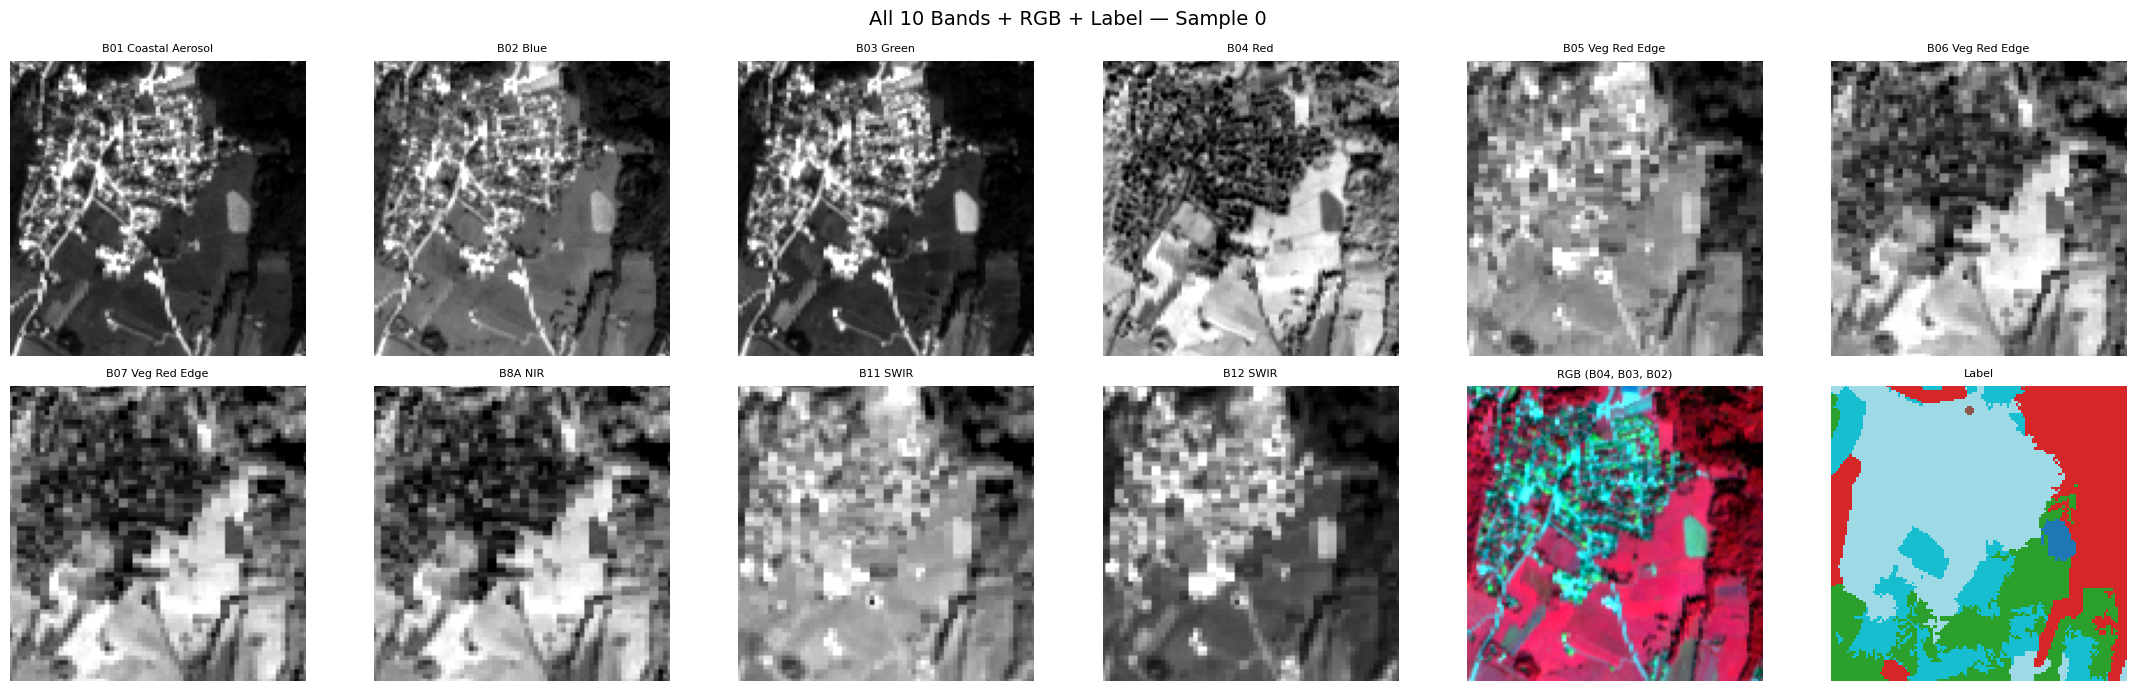

Plot saved to segmunich_sample0.png


In [36]:
BAND_LABELS = [
    "B01 Coastal Aerosol", "B02 Blue",     "B03 Green",        "B04 Red",
    "B05 Veg Red Edge",    "B06 Veg Red Edge", "B07 Veg Red Edge", "B8A NIR",
    "B11 SWIR",            "B12 SWIR",
]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle("All 10 Bands + RGB + Label — Sample 0", fontsize=14)

all_axes = iter(axes.flat)

for i in range(10):
    ax = next(all_axes)
    ax.imshow(norm(optical[i]), cmap="gray")
    ax.set_title(BAND_LABELS[i], fontsize=8)
    ax.axis("off")

ax = next(all_axes)
ax.imshow(norm(sample["rgb"]))
ax.set_title("RGB (B04, B03, B02)", fontsize=8)
ax.axis("off")

ax = next(all_axes)
ax.imshow(label.numpy(), cmap="tab20", interpolation="nearest")
ax.set_title("Label", fontsize=8)
ax.axis("off")

plt.tight_layout()
plt.savefig("segmunich_sample0.png", dpi=150)
plt.show()
print("Plot saved to segmunich_sample0.png")